Coeficiente de Restitución - Tracker
Este script procesa un video de una pelota rebotando para encontrar el coeficiente de restitución ($e$).
Implementado con OpenCV y SciPy.


In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import os


1. Funciones de Detección (Reutilizadas de Gravity Tracker)


In [8]:
def detect_ball(frame, lower_hsv, upper_hsv, min_area=50):
    """Detecta la bola en un frame dado un rango de color HSV. Retorna el centroide (cx, cy)."""
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, lower_hsv, upper_hsv)
    
    # Limpieza morfológica
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, mask
        
    largest = max(contours, key=cv2.contourArea)
    if cv2.contourArea(largest) < min_area:
        return None, mask
        
    M = cv2.moments(largest)
    if M["m00"] == 0:
        return None, mask
        
    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])
    return (cx, cy), mask


2. Módulo de Interacción y Calibración HSV


In [9]:
def interactive_hsv_calibration(video_path):
    """Abre una ventana con sliders para ajustar la detección de color iterativamente."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"No se pudo cargar el video: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    cv2.namedWindow("Ajuste HSV", cv2.WINDOW_NORMAL)
    cv2.resizeWindow("Ajuste HSV", 1000, 600)
    
    # Valores iniciales (para una pelota roja/naranja por defecto)
    cv2.createTrackbar("H min", "Ajuste HSV", 0, 180, lambda x: None)
    cv2.createTrackbar("H max", "Ajuste HSV", 25, 180, lambda x: None)
    cv2.createTrackbar("S min", "Ajuste HSV", 100, 255, lambda x: None)
    cv2.createTrackbar("S max", "Ajuste HSV", 255, 255, lambda x: None)
    cv2.createTrackbar("V min", "Ajuste HSV", 100, 255, lambda x: None)
    cv2.createTrackbar("V max", "Ajuste HSV", 255, 255, lambda x: None)
    cv2.createTrackbar("Frame", "Ajuste HSV", 0, total_frames - 1, lambda x: None)

    last_frame_pos = -1
    sample_frame = None

    print("\n--- INSTRUCCIONES DE AJUSTE HSV ---")
    print("1. Usa el Slider 'Frame' o teclas 'd' (Avanzar) y 'a' (Retroceder) para buscar la pelota en el video.")
    print("2. Ajusta los sliders de color hasta que LA ÚNICA parte blanca en la máscara sea la pelota.")
    print("3. Presiona ENTER para confirmar.")
    
    while True:
        pos = cv2.getTrackbarPos("Frame", "Ajuste HSV")
        if pos != last_frame_pos:
            cap.set(cv2.CAP_PROP_POS_FRAMES, pos)
            ret, frame = cap.read()
            if ret:
                sample_frame = frame
                last_frame_pos = pos

        if sample_frame is None:
            break

        h_min, h_max = cv2.getTrackbarPos("H min", "Ajuste HSV"), cv2.getTrackbarPos("H max", "Ajuste HSV")
        s_min, s_max = cv2.getTrackbarPos("S min", "Ajuste HSV"), cv2.getTrackbarPos("S max", "Ajuste HSV")
        v_min, v_max = cv2.getTrackbarPos("V min", "Ajuste HSV"), cv2.getTrackbarPos("V max", "Ajuste HSV")
        
        lower_hsv = np.array([h_min, s_min, v_min])
        upper_hsv = np.array([h_max, s_max, v_max])

        center, mask = detect_ball(sample_frame, lower_hsv, upper_hsv)

        vis = sample_frame.copy()
        if center:
            cv2.circle(vis, center, 10, (0, 255, 0), 2)
            cv2.putText(vis, "DETECTADO", (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
            
        combined = np.hstack([vis, cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)])
        # cv2.imshow("Ajuste HSV", combined)

        key = cv2.waitKey(30) & 0xFF
        if key in [13, 32]: # ENTER / SPACE
            break
        elif key == ord('d'):
            cv2.setTrackbarPos("Frame", "Ajuste HSV", min(pos + 5, total_frames - 1))
        elif key == ord('a'):
            cv2.setTrackbarPos("Frame", "Ajuste HSV", max(pos - 5, 0))

    cv2.destroyWindow("Ajuste HSV")
    cap.release()
    return lower_hsv, upper_hsv


3. Procesamiento y Extracción de Datos de Vuelo


In [10]:
def process_video_tracking(video_path, lower_hsv, upper_hsv):
    """Recorre el video frame a frame para guardar el historial de (X, Y)"""
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    time_series = []
    y_series = []
    
    frame_idx = 0
    print("\nProcesando seguimiento en el video...")
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        center, _ = detect_ball(frame, lower_hsv, upper_hsv)
        if center:
            t = frame_idx / fps
            time_series.append(t)
            y_series.append(center[1])  # Solo nos interesa la Y para los rebotes
            
            # Simple UI de carga / visualización (opcional)
            vis = frame.copy()
            cv2.circle(vis, center, 8, (255, 0, 0), -1)
            # cv2.imshow
            # cv2.waitKey
            
        frame_idx += 1

    # cv2.destroyAllWindows()
    cap.release()
    print(f"Seguimiento completado. {len(time_series)} frames registrados.")
    return np.array(time_series), np.array(y_series)


4. Análisis de Restitución y Gráficas ($e$)


In [11]:
def compute_restitution(time_series, y_pixels):
    """Calcula matemáticamente el coeficiente de restitución usando picos usando scipy"""
    
    # IMPORTANTE: En OpenCV, hacia 'abajo' (el piso) => es un Y MAYOR.
    # Así que el "piso" es el Y máximo alcanzado en el registro.
    y_floor = np.percentile(y_pixels, 98) # ignorar posibles atípicos
    
    # La altura sobre el piso en píxeles:
    # h = (piso - posición_y)
    heights = y_floor - y_pixels
    
    # Extraer los "rebotes" buscando los máximos locales de la "altura" h.
    # Prominence evita que pequeñas vibraciones sean tomadas como rebotes gigantes.
    peaks_indices, _ = find_peaks(heights, prominence=20, distance=5)
    
    peak_times = time_series[peaks_indices]
    peak_heights = heights[peaks_indices]
    
    # Calcular el coeficiente de restitución (e) por cada par de saltos continuos
    # e = sqrt(h_n+1 / h_n)
    coefficients = []
    for i in range(len(peak_heights) - 1):
        h_n = peak_heights[i]
        h_next = peak_heights[i+1]
        
        # Filtro de seguridad (que no salte más alto mágicamente ignorando viento o ruido)
        if h_next < h_n and h_n > 0: 
            e = np.sqrt(h_next / h_n)
            coefficients.append(e)

    avg_e = np.mean(coefficients) if coefficients else 0
    std_e = np.std(coefficients) if coefficients else 0
    
    # -- GRÁFICA --
    plt.figure(figsize=(10, 5))
    plt.plot(time_series, heights, label="Trayectoria (Pixeles sobre el suelo)", color="#3b82f6")
    plt.plot(peak_times, peak_heights, "x", color="#ef4444", markersize=10, 
             label="Picos Detectados (Máximos iterativos)")
    
    for i, txt in enumerate(peak_heights):
        plt.annotate(f"{txt:.0f}px", (peak_times[i], peak_heights[i] + 5), fontsize=9)
        
    plt.title(f"Rebotes Detectados - Coef. de Restitución Promedio (e) = {avg_e:.3f} ± {std_e:.3f}")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Altura Relativa (px)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Guardar localmente
    out_path = os.path.join(os.getcwd(), "restitution_plot.png")
    plt.savefig(out_path, dpi=150)
    print(f"\n📊 Resultados Guardados en: {out_path}")
    
    plt.show()
    return avg_e


5. Controlador Principal (Main)
Puedes ejecutar esta celda de un jalón en tu cuaderno Jupyter, o lanzar el script desde tu Bento.


Rango Seleccionado: [  0 100 100] -> [ 10 255 255]

Procesando seguimiento en el video...
Seguimiento completado. 210 frames registrados.

📊 Resultados Guardados en: /Users/apple/Desktop/Universidad/Sensado y Sistemas Fisicos/Sensado_y_modeladoSF/03_coefficient_restitution/restitution_plot.png


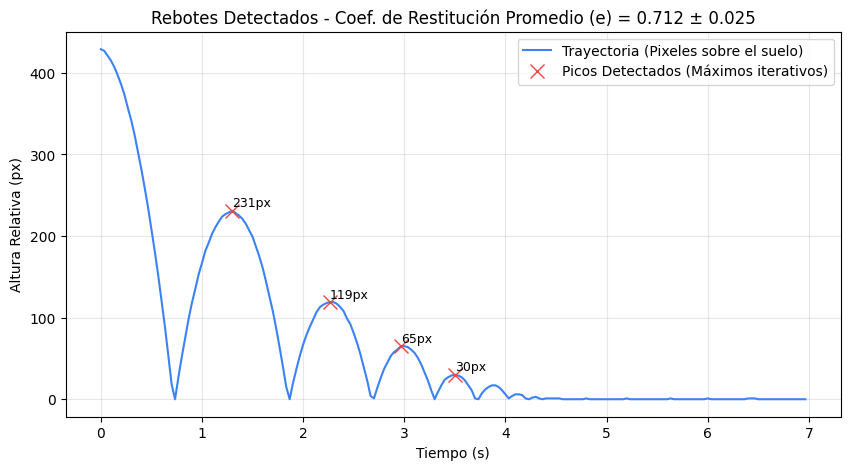

----------------------------------------
  👉 Coeficiente e = 0.7121
----------------------------------------


In [12]:
if __name__ == "__main__":
    base_dir = os.getcwd()
    video_path = os.path.join(base_dir, "video.mp4")
    
    if not os.path.exists(video_path):
        print(f"ERROR: No se encontró el archivo de video en {video_path}")
    else:
        # 1. Calibrar (Interactividad del desarrollador)
        lower_hsv = np.array([0, 100, 100])
        upper_hsv = np.array([10, 255, 255])
        # lower_hsv, upper_hsv = interactive_hsv_calibration(video_path)
        print(f"Rango Seleccionado: {lower_hsv} -> {upper_hsv}")
        
        # 2. Tracking de la pelota y generar matriz (Time vs Y)
        t_hist, y_hist = process_video_tracking(video_path, lower_hsv, upper_hsv)
        
        # 3. Matemática e inyección a SciPy
        if len(y_hist) > 10:
            e = compute_restitution(t_hist, y_hist)
            print("-" * 40)
            print(f"  👉 Coeficiente e = {e:.4f}")
            print("-" * 40)
        else:
            print("No se encontraron suficientes puntos de trackeo para analizar el rebote.")
